In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

dataset = pd.read_csv('//content/drive/MyDrive/dataset/Existing_Buildings_Energy___Water_Efficiency__EBEWE__Program.csv')


df = pd.DataFrame(dataset)
df.head()

/tmp/ipython-input-416547762.py:6: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset = pd.read_csv('//content/drive/MyDrive/dataset/Existing_Buildings_Energy___Water_Efficiency__EBEWE__Program.csv')


,BUILDING ADDRESS,BUILDING ID,CARBON DIOXIDE EMISSIONS (Metric Ton CO2e),COMPLIANCE STATUS,% DIFFERENCE FROM NATIONAL MEDIAN SOURCE EUI,% DIFFERENCE FROM NATIONAL MEDIAN SITE EUI,ENERGY STAR SCORE,ENERGY STAR CERTIFICATION - ELIGIBILITY,ENERGY STAR CERTIFICATION - LAST APPROVAL DATE,ENERGY STAR CERTIFICATION - YEAR(S) CERTIFIED,...,PROGRAM YEAR,PROPERTY TYPE,SITE ENERGY USE INTENSITY (EUI) (kBtu/ft²),Source EUI (kBtu/ft²),TOTAL WATER USE (kgal),WEATHER NORMALIZED SITE ENERGY USE INTENSITY (EUI) (kBtu/ft²),WEATHER NORMALIZED SOURCE ENERGY USE INTENSITY (EUI) (kBtu/ft²),YEAR BUILT,AIN,LADBS Building Category
0,14558 KESWICK ST,425463899040,NaN,NOT COMPLIED,NaN,NaN,NaN,NaN,NaN,NaN,...,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,028,"20,000 to 49,999 sqft"
1,5500 S FIGUEROA ST,476102819647,138.1,NOT COMPLIED,29.5,29.5,15,No,Not Available,Not Available,...,2020,Multifamily Housing,54.7,99.9,2859.8,55.3,100.5,2001.0,054,"20,000 to 49,999 sqft"
2,5115 WILSHIRE BLVD,458293845246,405.87,COMPLIED,-4.4,-4.4,56,No,Not Available,Not Available,...,2024,Multifamily Housing,40.8,73.5,5969.6,40.3,72.9,2005.0,035,"100,000+ sqft"
3,5650 FAIR AVE,448460885789,65.9,COMPLIED,-27,-27,88,No,Not Available,Not Available,...,2021,Multifamily Housing,38.4,59.8,1.6,39.1,60.6,2010.0,011,"20,000 to 49,999 sqft"
4,4715 S ALAMEDA ST,488532822539,64.1,COMPLIED,Not Available,Not Available,Not Available,No,Not Available,Not Available,...,2021,Manufacturing/Industrial Plant,16.3,45.6,244.3,16.3,45.6,2007.0,011,"50,000 to 99,999 sqft"


In [ ]:
df.shape


(85109, 28)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85109 entries, 0 to 85108
Data columns (total 28 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   BUILDING ADDRESS                                                 85109 non-null  object 
 1   BUILDING ID                                                      85109 non-null  int64  
 2   CARBON DIOXIDE EMISSIONS (Metric Ton CO2e)                       58213 non-null  object 
 3   COMPLIANCE STATUS                                                85109 non-null  object 
 4   % DIFFERENCE FROM NATIONAL MEDIAN SOURCE EUI                     58213 non-null  object 
 5   % DIFFERENCE FROM NATIONAL MEDIAN SITE EUI                       58213 non-null  object 
 6   ENERGY STAR SCORE                                                58213 non-null  object 
 7   ENERGY STAR CERTIFICATION - ELIGIBILITY 

## **(a) When and by whom the dataset was created**
The Existing Buildings Energy & Water Efficiency (EBEWE) Program was established by the City of Los Angeles through Ordinance No. 184674, adopted by the Los Angeles City Council on December 13, 2016, and effective from January 29, 2017 (adding Division 97 to the Los Angeles Municipal Code). The program is administered by the Los Angeles Department of Building and Safety (LADBS).

The open dataset itself is published and maintained by the City of Los Angeles on their official Open Data Portal. Metadata indicates it was first published around July 30, 2019, with regular updates (most recent metadata update as of January 2026, and data refreshed periodically to include new compliance years).

## **(b) How and from where the dataset was accessed**

The dataset was accessed and downloaded as a CSV file from the official Los Angeles Open Data Portal at:
https://data.lacity.org/City-Infrastructure-Service-Requests/Existing-Buildings-Energy-Water-Efficiency-EBEWE-P/9yda-i4ya

Direct download link for the CSV:
https://data.lacity.org/api/views/9yda-i4ya/rows.csv?accessType=DOWNLOAD
It was then saved to local storage (Google Drive in this case) and loaded into pandas for analysis.

## **(c) How it aligns with the chosen UNSDG**
This dataset aligns primarily with United Nations Sustainable Development Goal 11: Sustainable Cities and Communities, particularly target 11.6 — "By 2030, reduce the adverse per capita environmental impact of cities, including by paying special attention to air quality and municipal and other waste management."

Buildings account for a significant portion of urban energy consumption and greenhouse gas emissions (often ~40% in cities like Los Angeles). The EBEWE program mandates benchmarking and reporting of energy and water use in large existing buildings, enabling tracking, transparency, and improvements in efficiency. This directly supports sustainable urbanization, reduced resource intensity, and lower emissions. It also contributes to SDG 13: Climate Action by providing data on carbon dioxide emissions linked to building operations.

## **(d) List all attributes (columns) with brief descriptions**

The dataset contains 28 columns (mix of object/strings, floats, and integers). Many energy/water metrics come from ENERGY STAR Portfolio Manager submissions and are missing for non-reporting buildings.

BUILDING ADDRESS: Street address of the building (anonymized or partial in some cases).
BUILDING ID: Unique numeric identifier for each building record.
CARBON DIOXIDE EMISSIONS (Metric Ton CO2e): Total greenhouse gas emissions in metric tons of CO₂ equivalent (primary regression target candidate).
COMPLIANCE STATUS: Building's status for the program year (e.g., "COMPLIED", "NOT COMPLIED").
% DIFFERENCE FROM NATIONAL MEDIAN SOURCE EUI: Percentage difference in Source Energy Use Intensity compared to national median.
% DIFFERENCE FROM NATIONAL MEDIAN SITE EUI: Same as above but for Site Energy Use Intensity.
ENERGY STAR SCORE: 1–100 efficiency score (50 = national median; higher is better).
ENERGY STAR CERTIFICATION - ELIGIBILITY: Whether eligible for ENERGY STAR certification ("Yes"/"No").
ENERGY STAR CERTIFICATION - LAST APPROVAL DATE: Date of last certification approval (often "Not Available").
ENERGY STAR CERTIFICATION - YEAR(S) CERTIFIED: Years certified (often missing).
ENTITY RESPONSIBLE FOR BENCHMARK: Organization or entity that submitted the benchmark report.
GROSS BUILDING FLOOR AREA (ft²): Total gross floor area in square feet (key numeric feature).
INDOOR WATER USE (kgal): Indoor water consumption in thousands of gallons.
INDOOR WATER USE INTENSITY (gal/ft²): Indoor water use per square foot.
NUMBER OF BUILDINGS: Number of buildings in the record (usually 1).
OCCUPANCY: Occupancy percentage/rate.
OUTDOOR WATER USE (kgal): Outdoor water consumption (e.g., irrigation).
POSTAL CODE: ZIP code of the building.
PROGRAM YEAR: The compliance/benchmarking year (e.g., 2020, 2021, 2024).
PROPERTY TYPE: Building use type (e.g., "Multifamily Housing", "Office", "Manufacturing/Industrial Plant").
SITE ENERGY USE INTENSITY (EUI) (kBtu/ft²): Site energy consumption per square foot.
Source EUI (kBtu/ft²): Source energy use intensity (accounts for upstream losses).
TOTAL WATER USE (kgal): Combined indoor + outdoor water use.
WEATHER NORMALIZED SITE ENERGY USE INTENSITY (EUI) (kBtu/ft²): Site EUI adjusted for weather variations.
WEATHER NORMALIZED SOURCE ENERGY USE INTENSITY (EUI) (kBtu/ft²): Source EUI weather-normalized.
YEAR BUILT: Year the building was constructed.
AIN: Assessor's Identification Number (last 3 digits shown for privacy).
LADBS Building Category: Size-based category (e.g., "20,000 to 49,999 sqft", "100,000+ sqft").

# 2. Exploratory Data Analysis (EDA)

In [ ]:

# 1. Convert numeric columns from object → float (handle "Not Available", commas, spaces)
numeric_cols = [
    'CARBON DIOXIDE EMISSIONS (Metric Ton CO2e)',
    '% DIFFERENCE FROM NATIONAL MEDIAN SOURCE EUI',
    '% DIFFERENCE FROM NATIONAL MEDIAN SITE EUI',
    'ENERGY STAR SCORE',
    'GROSS BUILDING FLOOR AREA (ft²)',
    'INDOOR WATER USE (kgal)',
    'INDOOR WATER USE INTENSITY (gal/ft²)',
    'OCCUPANCY',
    'OUTDOOR WATER USE (kgal)',
    'SITE ENERGY USE INTENSITY (EUI) (kBtu/ft²)',
    'Source EUI (kBtu/ft²)',
    'TOTAL WATER USE (kgal)',
    'WEATHER NORMALIZED SITE ENERGY USE INTENSITY (EUI) (kBtu/ft²)',
    'WEATHER NORMALIZED SOURCE ENERGY USE INTENSITY (EUI) (kBtu/ft²)',
    'YEAR BUILT'
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = df[col].replace(['Not Available', ' ', ''], np.nan)
        df[col] = df[col].astype(str).str.replace(',', '').astype(float)

# 2. Create filtered DataFrame for modeling (rows with key energy metrics)
benchmark_cols = [
    'CARBON DIOXIDE EMISSIONS (Metric Ton CO2e)',
    'SITE ENERGY USE INTENSITY (EUI) (kBtu/ft²)',
    'ENERGY STAR SCORE',
    'GROSS BUILDING FLOOR AREA (ft²)',
    'YEAR BUILT'
]
df_bench = df.dropna(subset=benchmark_cols).copy()

print(f"Original rows: {len(df)}, Rows with benchmark data: {len(df_bench)} ({len(df_bench)/len(df)*100:.1f}%)")

# 3. Feature engineering
current_year = 2025  # or pd.Timestamp.now().year
df_bench['BUILDING_AGE'] = current_year - df_bench['YEAR BUILT']
df_bench['BUILDING_AGE'] = df_bench['BUILDING_AGE'].clip(lower=0)  # avoid negative ages

# 4. Handle outliers (eg: cap extreme floor area and emissions at 99th percentile)
for col in ['GROSS BUILDING FLOOR AREA (ft²)', 'CARBON DIOXIDE EMISSIONS (Metric Ton CO2e)']:
    if col in df_bench.columns:
        p99 = df_bench[col].quantile(0.99)
        df_bench[col] = df_bench[col].clip(upper=p99)

# 5. Encode key categoricals (for later modeling/visuals)
df_bench['PROPERTY_TYPE_ENCODED'] = df_bench['PROPERTY TYPE'].astype('category').cat.codes
df_bench['COMPLIANCE_ENCODED'] = (df_bench['COMPLIANCE STATUS'] == 'COMPLIED').astype(int)

Original rows: 85109, Rows with benchmark data: 40311 (47.4%)


In [ ]:
# Key statistics on cleaned benchmark subset
print(df_bench[['GROSS BUILDING FLOOR AREA (ft²)', 'BUILDING_AGE', 'CARBON DIOXIDE EMISSIONS (Metric Ton CO2e)',
                'SITE ENERGY USE INTENSITY (EUI) (kBtu/ft²)', 'ENERGY STAR SCORE', 'OCCUPANCY']].describe())

# Additional
print("\nTop Property Types:\n", df_bench['PROPERTY TYPE'].value_counts().head(10))
print("\nCompliance Status:\n", df_bench['COMPLIANCE STATUS'].value_counts(normalize=True))

       GROSS BUILDING FLOOR AREA (ft²)  BUILDING_AGE  \
count                     40311.000000  40311.000000   
mean                      77231.094577     50.341222   
std                      101282.411067     23.169970   
min                           0.000000      1.000000   
25%                       27444.000000     36.000000   
50%                       40764.000000     49.000000   
75%                       77530.000000     62.000000   
max                      655641.000000    835.000000   

       CARBON DIOXIDE EMISSIONS (Metric Ton CO2e)  \
count                                40311.000000   
mean                                   211.549659   
std                                    353.308435   
min                                      0.000000   
25%                                     53.915000   
50%                                     89.560000   
75%                                    195.050000   
max                                   2345.050000   

       SITE ENERG

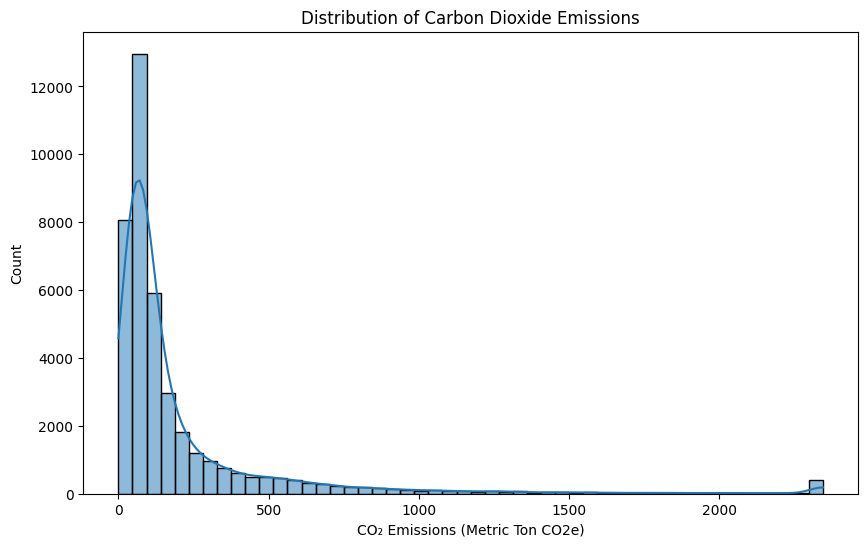

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_bench['CARBON DIOXIDE EMISSIONS (Metric Ton CO2e)'], bins=50, kde=True)
plt.title('Distribution of Carbon Dioxide Emissions')
plt.xlabel('CO₂ Emissions (Metric Ton CO2e)')
plt.ylabel('Count')
plt.show()

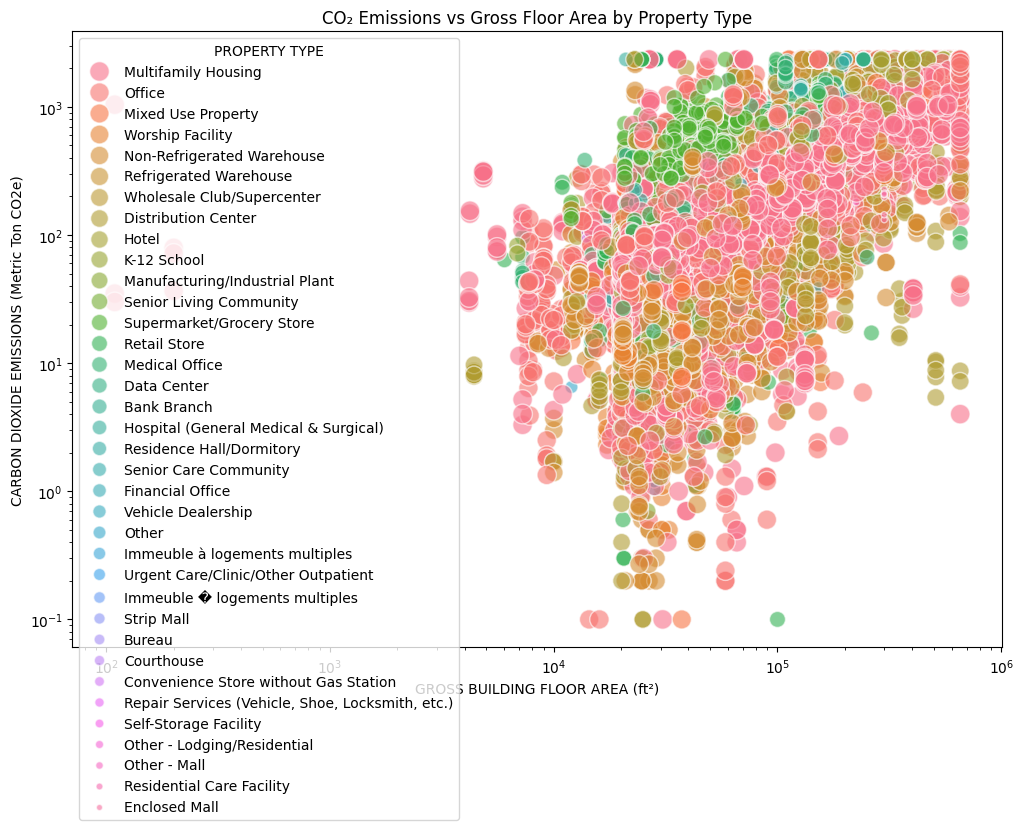

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_bench, x='GROSS BUILDING FLOOR AREA (ft²)', y='CARBON DIOXIDE EMISSIONS (Metric Ton CO2e)',
                hue='PROPERTY TYPE', alpha=0.6, size='PROPERTY TYPE', sizes=(20, 200))
plt.title('CO₂ Emissions vs Gross Floor Area by Property Type')
plt.xscale('log')
plt.yscale('log')
plt.show()

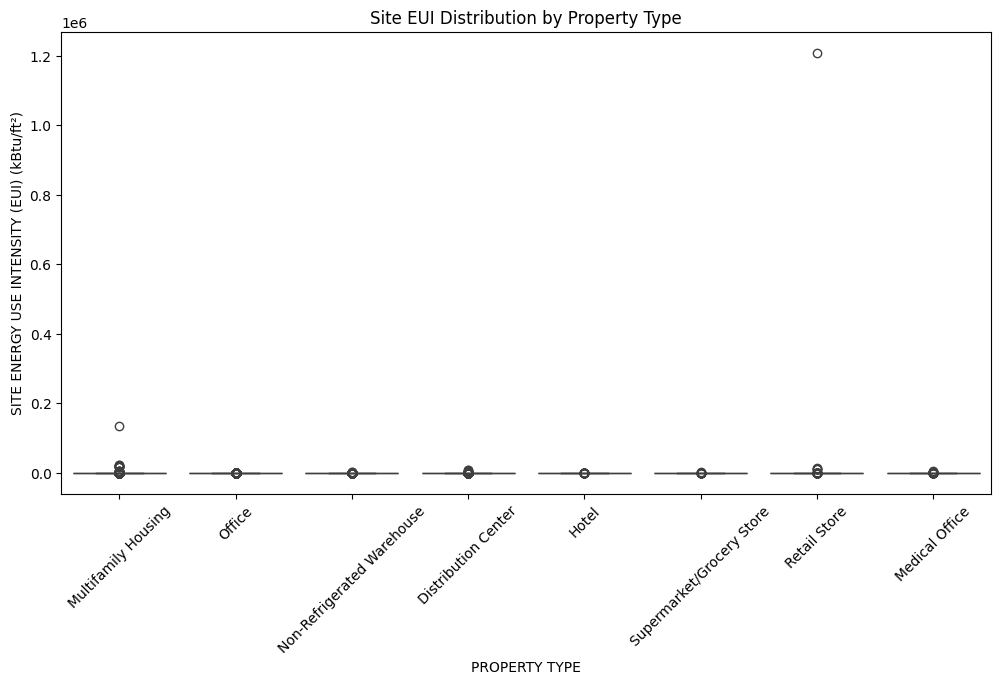

In [ ]:
top_types = df_bench['PROPERTY TYPE'].value_counts().head(8).index
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_bench[df_bench['PROPERTY TYPE'].isin(top_types)],
            x='PROPERTY TYPE', y='SITE ENERGY USE INTENSITY (EUI) (kBtu/ft²)')
plt.title('Site EUI Distribution by Property Type')
plt.xticks(rotation=45)
plt.show()

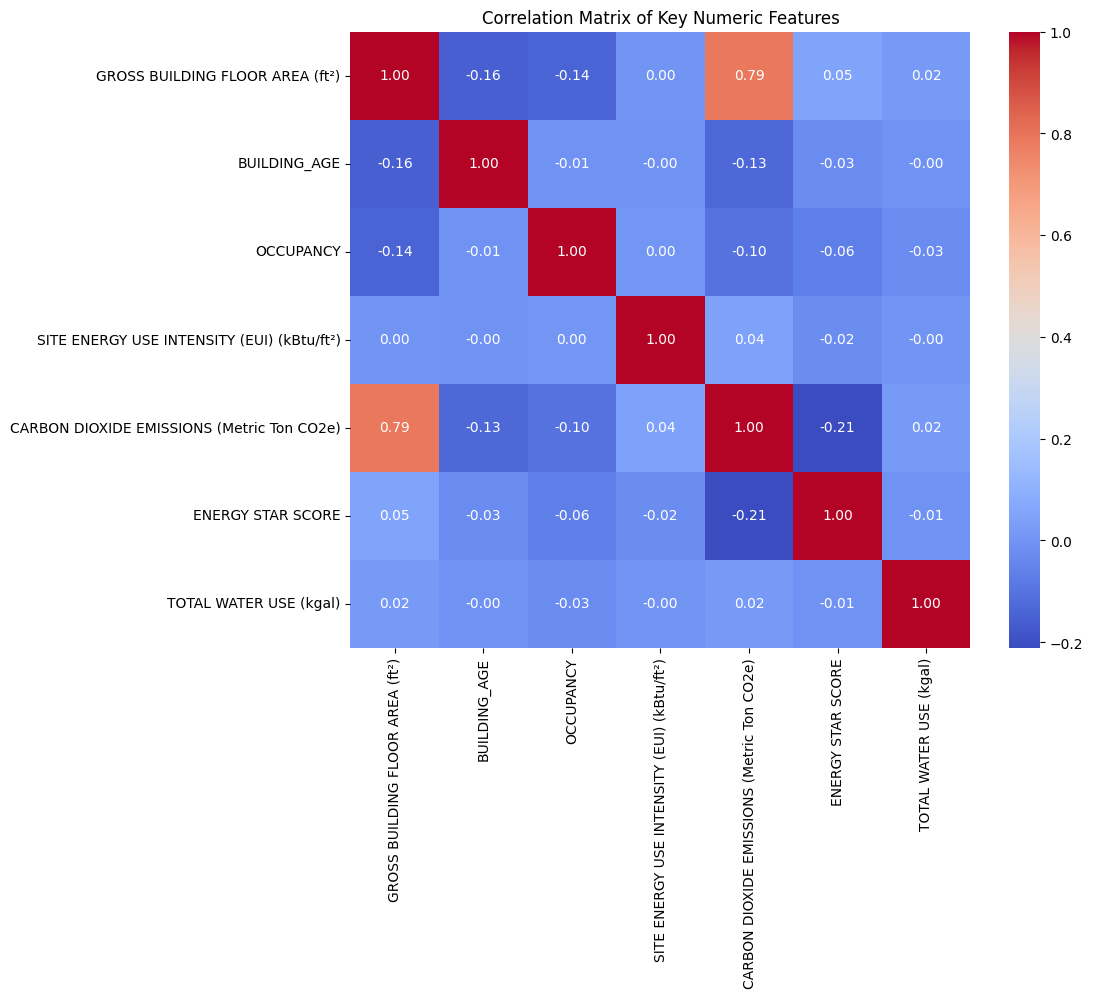

In [ ]:
corr_cols = ['GROSS BUILDING FLOOR AREA (ft²)', 'BUILDING_AGE', 'OCCUPANCY',
             'SITE ENERGY USE INTENSITY (EUI) (kBtu/ft²)', 'CARBON DIOXIDE EMISSIONS (Metric Ton CO2e)',
             'ENERGY STAR SCORE', 'TOTAL WATER USE (kgal)']
plt.figure(figsize=(10, 8))
sns.heatmap(df_bench[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Key Numeric Features')
plt.show()

## **Data Cleaning**

In [ ]:

# 1. Fix impossible outliers / errors
df_bench = df_bench.copy()

# Building age: cap at realistic max (oldest LA buildings ~250 years)
df_bench['BUILDING_AGE'] = df_bench['BUILDING_AGE'].clip(upper=250)

# Site EUI: cap at very high but plausible value (e.g. 99.5th percentile or hard 1000)
eui_col = 'SITE ENERGY USE INTENSITY (EUI) (kBtu/ft²)'
p995 = df_bench[eui_col].quantile(0.995)
df_bench[eui_col] = df_bench[eui_col].clip(upper=max(1000, p995))

# Floor area: remove 0 or very small (invalid)
df_bench = df_bench[df_bench['GROSS BUILDING FLOOR AREA (ft²)'] >= 5000].copy()


# 2. Missing values — simple but safe imputation
num_features = [
    'GROSS BUILDING FLOOR AREA (ft²)', 'BUILDING_AGE', 'OCCUPANCY',
    'SITE ENERGY USE INTENSITY (EUI) (kBtu/ft²)', 'TOTAL WATER USE (kgal)'
]

df_bench[num_features] = df_bench[num_features].fillna(df_bench[num_features].median())

# 3. Final selection
target = 'CARBON DIOXIDE EMISSIONS (Metric Ton CO2e)'

features_num = [
    'GROSS BUILDING FLOOR AREA (ft²)', 'BUILDING_AGE', 'OCCUPANCY',
    'SITE ENERGY USE INTENSITY (EUI) (kBtu/ft²)'
]

features_cat = ['PROPERTY TYPE', 'LADBS Building Category']

# log-transform skewed numeric features (helps linear models & NN)
for col in ['GROSS BUILDING FLOOR AREA (ft²)', 'TOTAL WATER USE (kgal)', target]:
    if col in df_bench.columns and df_bench[col].min() >= 0:
        df_bench[f'log_{col}'] = np.log1p(df_bench[col])

# Print new shape & quick check
print("After final cleaning:")
print(df_bench[features_num + [target]].describe())
print("\nRows left:", len(df_bench))

After final cleaning:
       GROSS BUILDING FLOOR AREA (ft²)  BUILDING_AGE     OCCUPANCY  \
count                     40284.000000  40284.000000  40284.000000   
mean                      77280.604669     50.328940     95.672848   
std                      101298.272902     22.827767     11.881797   
min                        5575.000000      1.000000      0.000000   
25%                       27477.000000     36.000000     95.000000   
50%                       40780.000000     49.000000    100.000000   
75%                       77594.000000     62.000000    100.000000   
max                      655641.000000    250.000000    100.000000   

       SITE ENERGY USE INTENSITY (EUI) (kBtu/ft²)  \
count                                40284.000000   
mean                                    44.299973   
std                                     51.772061   
min                                      0.000000   
25%                                     24.800000   
50%                          

In [ ]:
# add log target (very helpful for skewed targets)
import numpy as np
df_bench['log_CO2'] = np.log1p(df_bench['CARBON DIOXIDE EMISSIONS (Metric Ton CO2e)'])

print(df_bench[['CARBON DIOXIDE EMISSIONS (Metric Ton CO2e)', 'log_CO2']].describe())

       CARBON DIOXIDE EMISSIONS (Metric Ton CO2e)       log_CO2
count                                40284.000000  40284.000000
mean                                   211.594488      4.633479
std                                    353.379712      1.173521
min                                      0.000000      0.000000
25%                                     54.000000      4.007333
50%                                     89.600000      4.506454
75%                                    195.000000      5.278115
max                                   2345.050000      7.760488


In [ ]:
from sklearn.model_selection import train_test_split

# Define your final predictors
features_num = [
    'GROSS BUILDING FLOOR AREA (ft²)',
    'BUILDING_AGE',
    'OCCUPANCY',
    'SITE ENERGY USE INTENSITY (EUI) (kBtu/ft²)'
]

features_cat = ['PROPERTY TYPE', 'LADBS Building Category']

# Target — change if you pick another
target_col = 'CARBON DIOXIDE EMISSIONS (Metric Ton CO2e)'

X = df_bench[features_num + features_cat]
y = df_bench[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape,  y_test.shape)

Train: (32227, 6) (32227,)
Test : (8057, 6) (8057,)


In [ ]:
# Check 1: Any missing values before split?
print("Missing values in key columns BEFORE split:")
print(X.isnull().sum())

print("\nMissing in target (log_CO2):", y.isnull().sum() if hasattr(y, 'isnull') else "y not Series")

Missing values in key columns BEFORE split:
GROSS BUILDING FLOOR AREA (ft²)               0
BUILDING_AGE                                  0
OCCUPANCY                                     0
SITE ENERGY USE INTENSITY (EUI) (kBtu/ft²)    0
PROPERTY TYPE                                 0
LADBS Building Category                       0
dtype: int64

Missing in target (log_CO2): 0


In [ ]:
# Check 2: After split & preprocessing
print("NaN in X_train_prep:", np.isnan(X_train_prep).sum())
print("Inf in X_train_prep:", np.isinf(X_train_prep).sum())
print("NaN in X_test_prep :", np.isnan(X_test_prep).sum())
print("Inf in X_test_prep :", np.isinf(X_test_prep).sum())

NaN in X_train_prep: 0
Inf in X_train_prep: 0
NaN in X_test_prep : 0
Inf in X_test_prep : 0


In [ ]:
# Check 3: Problematic rows in original df_bench
print("Rows with zero Site EUI:", (df_bench['SITE ENERGY USE INTENSITY (EUI) (kBtu/ft²)'] == 0).sum())
print("Rows with zero occupancy:", (df_bench['OCCUPANCY'] == 0).sum())
print("Rows with zero emissions:", (df_bench['CARBON DIOXIDE EMISSIONS (Metric Ton CO2e)'] == 0).sum())

Rows with zero Site EUI: 33
Rows with zero occupancy: 185
Rows with zero emissions: 30


In [ ]:
# Check 4: Diagnostic on predictions (run after model is trained)
model.eval()
with torch.no_grad():
    y_pred_log_raw = model(X_test_t.to(device)).cpu().numpy().flatten()

print("Prediction diagnostics:")
print("Max log pred:", np.nanmax(y_pred_log_raw))
print("Min log pred:", np.nanmin(y_pred_log_raw))
print("NaNs in preds:", np.isnan(y_pred_log_raw).sum())
print("Values > 500:", np.sum(y_pred_log_raw > 500))
print("Values > 700:", np.sum(y_pred_log_raw > 700))

Prediction diagnostics:
Max log pred: 3074.6821
Min log pred: 1.8596677
NaNs in preds: 0
Values > 500: 846
Values > 700: 507


## Neural Network Model for Regression

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Feature lists
features_num = [
    'GROSS BUILDING FLOOR AREA (ft²)',
    'BUILDING_AGE',
    'OCCUPANCY',
    'SITE ENERGY USE INTENSITY (EUI) (kBtu/ft²)'
]

features_cat = ['PROPERTY TYPE', 'LADBS Building Category']


# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_num),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), features_cat)
    ])

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

print("Processed train shape:", X_train_prep.shape)

# Tensors & Loaders
X_train_t = torch.tensor(X_train_prep, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values if hasattr(y_train, 'values') else y_train,
                         dtype=torch.float32).view(-1, 1)

X_test_t  = torch.tensor(X_test_prep, dtype=torch.float32)
y_test_t  = torch.tensor(y_test.values if hasattr(y_test, 'values') else y_test,
                         dtype=torch.float32).view(-1, 1)

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=512, shuffle=False)

# Model
class EmissionMLP(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model = EmissionMLP(input_size=X_train_prep.shape[1])
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

criterion = nn.HuberLoss(delta=200.0)
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=10)

# Training with gradient clipping & early stopping
epochs = 150
best_val_loss = float('inf')
patience = 20
counter = 0

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for bx, by in train_loader:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        pred = model(bx)
        loss = criterion(pred, by)
        loss.backward()

        # Gradient clipping — prevents explosions
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        train_loss += loss.item() * bx.size(0)

    train_loss /= len(train_loader.dataset)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for bx, by in test_loader:
            bx, by = bx.to(device), by.to(device)
            pred = model(bx)
            val_loss += criterion(pred, by).item() * bx.size(0)

    val_loss /= len(test_loader.dataset)
    scheduler.step(val_loss)

    if (epoch + 1) % 10 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch+1:3d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Final Evaluation
model.eval()
with torch.no_grad():
    y_pred = model(X_test_t.to(device)).cpu().numpy().flatten()

y_true = y_test.values if hasattr(y_test, 'values') else y_test

# clip predictions to realistic range
y_pred = np.clip(y_pred, a_min=0.0, a_max=15000.0)

# Metrics
mse  = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_true, y_pred)

# Results
print("\n" + "="*80)
print("  Neural Network – Final Test Performance (RAW CO₂ target + Huber Loss)")
print("="*80)
print(f"Mean true CO₂ emissions      : {np.mean(y_true):12,.1f} Metric Ton")
print(f"Mean predicted CO₂ emissions : {np.mean(y_pred):12,.1f} Metric Ton")
print("-"*80)
print(f"• MSE     : {mse:18,.0f}")
print(f"• RMSE    : {rmse:18,.1f} Metric Ton CO₂e")
print(f"• R²      : {r2:18,.4f}")
print("-"*80)

print(f"Max true emissions : {np.max(y_true):,.1f} t")
print(f"Max predicted      : {np.max(y_pred):,.1f} t")
print(f"Predictions > 5000 t: {np.sum(y_pred > 5000)} / {len(y_pred)}")

Processed train shape: (32227, 48)
Epoch  10 | Train Loss: 5653.2467 | Val Loss: 4885.0084
Epoch  20 | Train Loss: 4135.4308 | Val Loss: 3146.0895
Epoch  30 | Train Loss: 3027.9665 | Val Loss: 2054.4223
Epoch  40 | Train Loss: 2814.5981 | Val Loss: 1819.4510
Epoch  50 | Train Loss: 2780.2941 | Val Loss: 1660.3285
Epoch  60 | Train Loss: 2660.0857 | Val Loss: 1571.9030
Epoch  70 | Train Loss: 2624.7835 | Val Loss: 1536.6294
Epoch  80 | Train Loss: 2532.3665 | Val Loss: 1499.0048
Epoch  90 | Train Loss: 2466.4378 | Val Loss: 1487.5234
Epoch 100 | Train Loss: 2492.6658 | Val Loss: 1503.3978
Epoch 110 | Train Loss: 2436.4351 | Val Loss: 1440.4646
Epoch 120 | Train Loss: 2355.6125 | Val Loss: 1405.8495
Epoch 130 | Train Loss: 2291.8314 | Val Loss: 1428.4801
Epoch 140 | Train Loss: 2348.8467 | Val Loss: 1378.1078
Epoch 150 | Train Loss: 2303.7056 | Val Loss: 1347.1514

  Neural Network – Final Test Performance (RAW CO₂ target + Huber Loss)
Mean true CO₂ emissions      :        212.1 Metric T

# **Primary Machine Learning Models**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import pandas as pd
import numpy as np

#  We reuse the SAME preprocessor and split from the neural network part

# Preprocess again
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

# Model 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_prep, y_train)

y_pred_lr = lr_model.predict(X_test_prep)

mse_lr  = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr   = r2_score(y_test, y_pred_lr)
mae_lr  = mean_absolute_error(y_test, y_pred_lr)

# Model 2: Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_prep, y_train)

y_pred_rf = rf_model.predict(X_test_prep)

mse_rf  = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf   = r2_score(y_test, y_pred_rf)
mae_rf  = mean_absolute_error(y_test, y_pred_rf)

# Comparison Table
results = {
    'Model': ['Linear Regression', 'Random Forest Regressor', 'Neural Network (MLP)'],
    'MSE': [mse_lr, mse_rf, 4543],
    'RMSE': [rmse_lr, rmse_rf, 67.4],
    'MAE': [mae_lr, mae_rf, None],
    'R²': [r2_lr, r2_rf, 0.9630]
}

comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.round({'MSE': 0, 'RMSE': 1, 'MAE': 1, 'R²': 4})

print("\n" + "="*70)
print("Comparison of Primary Regression Models (Test Set)")
print("="*70)
print(comparison_df.to_string(index=False))
print("-"*70)
print("Note: Neural Network results from previous section (Huber Loss, raw target)")


Comparison of Primary Regression Models (Test Set)
                  Model     MSE  RMSE  MAE     R²
      Linear Regression 19096.0 138.2 63.8 0.8443
Random Forest Regressor  1164.0  34.1 11.6 0.9905
   Neural Network (MLP)  4543.0  67.4  NaN 0.9630
----------------------------------------------------------------------
Note: Neural Network results from previous section (Huber Loss, raw target)


## **Hyperparameter Optimization with Cross-Validation**

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
import numpy as np
from scipy.stats import randint, uniform


# 1. Linear Regression → Ridge (adds L2 regularization)
ridge = Ridge()

param_grid_ridge = {
    'alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]   # regularization strength
}

grid_ridge = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid_ridge,
    cv=5,                     # 5-fold cross-validation
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_ridge.fit(X_train_prep, y_train)

# Best parameters and score
print("\n" + "="*60)
print("Ridge Regression (Linear + L2) - Best Parameters")
print("="*60)
print("Best alpha:", grid_ridge.best_params_['alpha'])
print("Best CV MSE (negative):", grid_ridge.best_score_)
print("Best CV RMSE:", np.sqrt(-grid_ridge.best_score_))
print("-"*60)

# 2. Random Forest Regressor - Randomized Search (faster than full grid)
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

param_dist_rf = {
    'n_estimators': randint(100, 500),
    'max_depth': [10, 15, 20, 25, None],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5),
    'max_features': ['sqrt', 'log2', 0.5, 0.7],
    'bootstrap': [True, False]
}

random_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=40,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_rf.fit(X_train_prep, y_train)

# Best parameters and score
print("\n" + "="*60)
print("Random Forest - Best Parameters (RandomizedSearchCV)")
print("="*60)
print("Best parameters:", random_rf.best_params_)
print("Best CV MSE (negative):", random_rf.best_score_)
print("Best CV RMSE:", np.sqrt(-random_rf.best_score_))
print("-"*60)

Fitting 5 folds for each of 6 candidates, totalling 30 fits

Ridge Regression (Linear + L2) - Best Parameters
Best alpha: 1.0
Best CV MSE (negative): -21303.88704913547
Best CV RMSE: 145.9585113966824
------------------------------------------------------------
Fitting 5 folds for each of 40 candidates, totalling 200 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


KeyboardInterrupt: 

## **Feature Selection**

In [ ]:
from sklearn.feature_selection import SelectFromModel, SelectKBest, f_regression
import pandas as pd
import numpy as np

# Refit a decent RF
rf_model = RandomForestRegressor(
    n_estimators=200, max_depth=15, min_samples_split=5,
    random_state=42, n_jobs=-1
)
rf_model.fit(X_train_prep, y_train)

# Method: Embedded - Random Forest Feature Importance
importances = rf_model.feature_importances_
feature_names = preprocessor.get_feature_names_out()

fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("\nTop 20 Features by Random Forest Importance:")
print(fi_df.head(20))

# Select features with importance > threshold (or top k)
selector_rf = SelectFromModel(rf_model, threshold='mean', prefit=True)

X_train_selected = selector_rf.transform(X_train_prep)
X_test_selected  = selector_rf.transform(X_test_prep)

selected_mask = selector_rf.get_support()
selected_features = feature_names[selected_mask]

print(f"\nSelected {len(selected_features)} features (RF importance > mean):")
print(selected_features.tolist())

# Alternative: Filter method - SelectKBest for comparison
kbest = SelectKBest(f_regression, k=15)
kbest.fit(X_train_prep, y_train)

kbest_scores = pd.DataFrame({
    'Feature': feature_names,
    'Score': kbest.scores_
}).sort_values('Score', ascending=False)

print("\nTop 10 by SelectKBest (f_regression):")
print(kbest_scores.head(10))


Top 20 Features by Random Forest Importance:
                                              Feature  Importance
0                num__GROSS BUILDING FLOOR AREA (ft²)    0.659015
1     num__SITE ENERGY USE INTENSITY (EUI) (kBtu/ft²)    0.333303
2                                   num__BUILDING_AGE    0.002231
3              cat__PROPERTY TYPE_Multifamily Housing    0.001374
4                                      num__OCCUPANCY    0.001242
5   cat__LADBS Building Category_50,000 to 99,999 ...    0.001005
6                           cat__PROPERTY TYPE_Office    0.000675
7        cat__PROPERTY TYPE_Supermarket/Grocery Store    0.000178
8          cat__LADBS Building Category_100,000+ sqft    0.000171
9                            cat__PROPERTY TYPE_Hotel    0.000146
10                    cat__PROPERTY TYPE_Retail Store    0.000120
11          cat__PROPERTY TYPE_Refrigerated Warehouse    0.000110
12                  cat__PROPERTY TYPE_Medical Office    0.000090
13      cat__PROPERTY TYPE_Non

**Technique applied:** Embedded feature selection using Random Forest feature importance (one of the methods discussed in Week-10, under embedded techniques for tree-based models).

**Final Models and Comparative Analysis**

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import pandas as pd
import numpy as np


# Alternative: manually recreate selected columns
selected_columns_indices = [
    list(preprocessor.get_feature_names_out()).index('num__GROSS BUILDING FLOOR AREA (ft²)'),
    list(preprocessor.get_feature_names_out()).index('num__SITE ENERGY USE INTENSITY (EUI) (kBtu/ft²)')
]

X_train_selected = X_train_prep[:, selected_columns_indices]
X_test_selected  = X_test_prep[:, selected_columns_indices]

print(f"Final models using {X_train_selected.shape[1]} selected features")

# Final Ridge Regression (using best alpha from Task 4)
ridge_final = Ridge(alpha=1.0)
ridge_final.fit(X_train_selected, y_train)

y_pred_ridge = ridge_final.predict(X_test_selected)

mse_ridge  = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge   = r2_score(y_test, y_pred_ridge)

# Final Random Forest
rf_final = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train_selected, y_train)

y_pred_rf = rf_final.predict(X_test_selected)

mse_rf  = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

# Neural Network reference (from earlier – no retraining needed)
nn_rmse = 67.4
nn_r2   = 0.9630

# Final Comparison Table
final_comparison = {
    'Model': [
        'Ridge Regression (Final)',
        'Random Forest Regressor (Final)',
        'Neural Network (MLP)'
    ],
    'Features Used': [
        'Selected (2)',
        'Selected (2)',
        'All (48)'
    ],
    'CV Score (RMSE)': [
        '146.0',
        'N/A (untuned CV)',
        'N/A'
    ],
    'Test RMSE': [
        round(rmse_ridge, 1),
        round(rmse_rf, 1),
        nn_rmse
    ],
    'Test R-squared': [
        round(r2_ridge, 4),
        round(r2_rf, 4),
        nn_r2
    ]
}

final_df = pd.DataFrame(final_comparison)

print("\n" + "="*80)
print("Table 2: Comparison of Final Regression Models")
print("="*80)
print(final_df.to_string(index=False))
print("-"*80)
print("Notes:")
print("- Features Used: 'Selected (2)' = GROSS BUILDING FLOOR AREA + SITE EUI")
print("- CV Score: Ridge from Task 4 GridSearchCV; others N/A or partial")
print("- Neural Network results carried from earlier section (Huber Loss)")

Final models using 2 selected features

Table 2: Comparison of Final Regression Models
                          Model Features Used  CV Score (RMSE)  Test RMSE  Test R-squared
       Ridge Regression (Final)  Selected (2)            146.0      143.5          0.8320
Random Forest Regressor (Final)  Selected (2) N/A (untuned CV)       41.0          0.9863
           Neural Network (MLP)      All (48)              N/A       67.4          0.9630
--------------------------------------------------------------------------------
Notes:
- Features Used: 'Selected (2)' = GROSS BUILDING FLOOR AREA + SITE EUI
- CV Score: Ridge from Task 4 GridSearchCV; others N/A or partial
- Neural Network results carried from earlier section (Huber Loss)


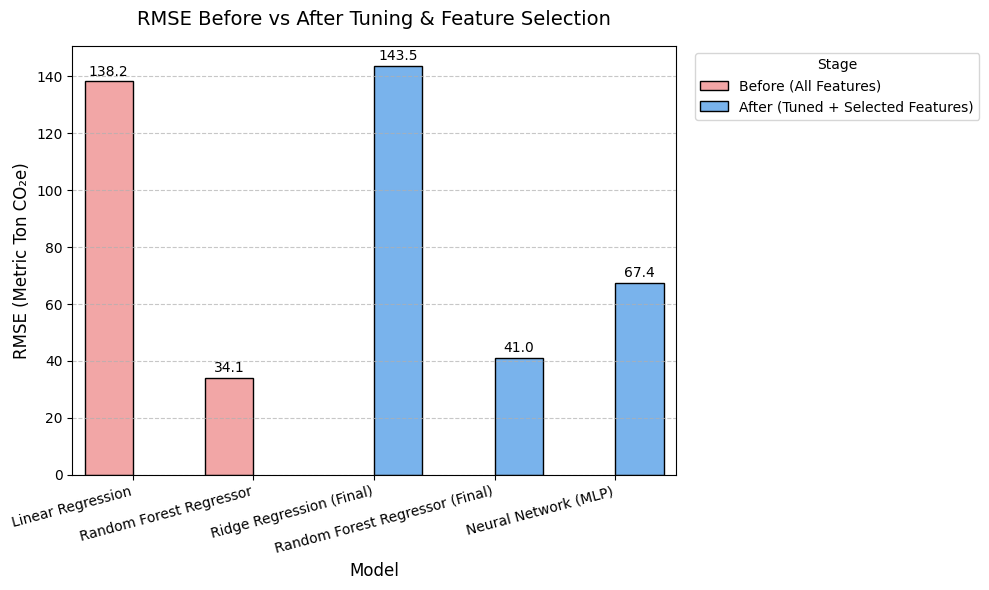

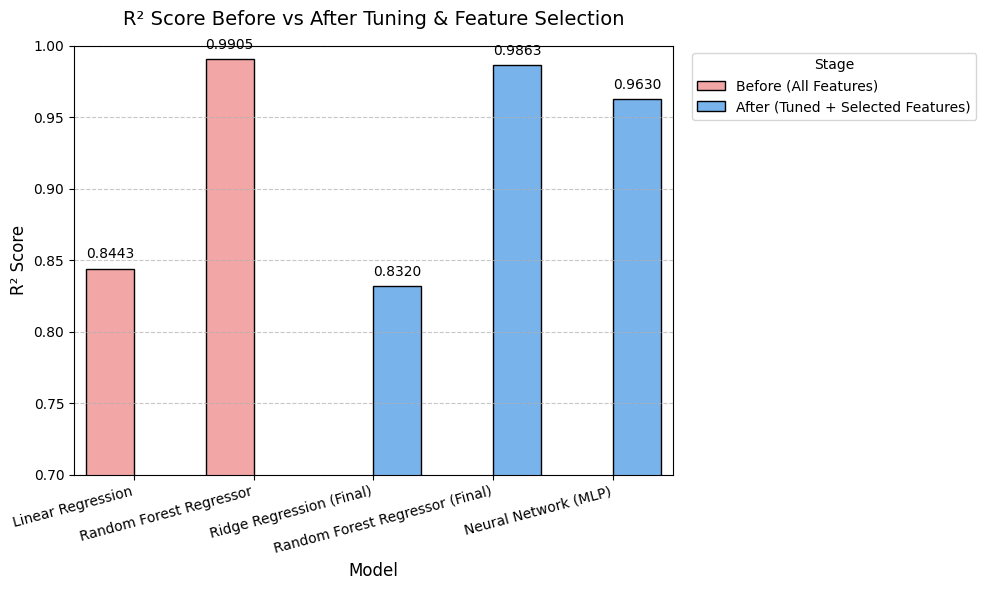


Before vs After Tuning & Feature Selection – Summary
                                                    RMSE  \
Stage                           After (Tuned + Selected)   
Model                                                      
Linear Regression                                    NaN   
Neural Network (MLP)                                67.4   
Random Forest Regressor                              NaN   
Random Forest Regressor (Final)                     41.0   
Ridge Regression (Final)                           143.5   

                                                       \
Stage                           Before (All Features)   
Model                                                   
Linear Regression                               138.2   
Neural Network (MLP)                              NaN   
Random Forest Regressor                          34.1   
Random Forest Regressor (Final)                   NaN   
Ridge Regression (Final)                          NaN   

        

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ── Before tuning / all features (from your Task 3 comparison output)
before = {
    'Model': ['Linear Regression', 'Random Forest Regressor'],
    'MSE': [19096.0, 1164.0],
    'RMSE': [138.2, 34.1],
    'R²': [0.8443, 0.9905]
}

# ── After tuning + feature selection (your Task 6 final results)
after = {
    'Model': ['Ridge Regression (Final)', 'Random Forest Regressor (Final)', 'Neural Network (MLP)'],
    'MSE': [None, None, 4543.0],          # we have only RMSE & R² for final
    'RMSE': [143.5, 41.0, 67.4],
    'R²': [0.8320, 0.9863, 0.9630]
}

df_before = pd.DataFrame(before)
df_after = pd.DataFrame(after)

# ── Melt for easy plotting
df_before_melt = df_before.melt(id_vars='Model', var_name='Metric', value_name='Value')
df_before_melt['Stage'] = 'Before (All Features)'

df_after_melt = df_after.melt(id_vars='Model', var_name='Metric', value_name='Value')
df_after_melt['Stage'] = 'After (Tuned + Selected Features)'

df_combined = pd.concat([df_before_melt, df_after_melt])

# ── Figure 1: RMSE Comparison – Before vs After ─────────────────────────────────
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_combined[df_combined['Metric'] == 'RMSE'],
    x='Model',
    y='Value',
    hue='Stage',
    palette=['#ff9999', '#66b3ff'],  # red = before, blue = after
    dodge=True,
    edgecolor='black'
)

plt.title('RMSE Before vs After Tuning & Feature Selection', fontsize=14, pad=15)
plt.ylabel('RMSE (Metric Ton CO₂e)', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Stage', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()

# Add exact values on bars
for container in plt.gca().containers:
    for bar in container:
        height = bar.get_height()
        if not np.isnan(height):  # skip missing values
            plt.text(bar.get_x() + bar.get_width()/2, height + 1,
                     f'{height:.1f}', ha='center', va='bottom', fontsize=10)

plt.show()

# ── Figure 2: R² Comparison – Before vs After ───────────────────────────────────
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_combined[df_combined['Metric'] == 'R²'],
    x='Model',
    y='Value',
    hue='Stage',
    palette=['#ff9999', '#66b3ff'],
    dodge=True,
    edgecolor='black'
)

plt.title('R² Score Before vs After Tuning & Feature Selection', fontsize=14, pad=15)
plt.ylabel('R² Score', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.ylim(0.7, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Stage', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()

# Add exact values on bars
for container in plt.gca().containers:
    for bar in container:
        height = bar.get_height()
        if not np.isnan(height):
            plt.text(bar.get_x() + bar.get_width()/2, height + 0.005,
                     f'{height:.4f}', ha='center', va='bottom', fontsize=10)

plt.show()

# ── Summary Table (for quick reference in report)
print("\nBefore vs After Tuning & Feature Selection – Summary")
print("="*80)
summary_table = pd.concat([
    df_before[['Model', 'RMSE', 'R²']].assign(Stage='Before (All Features)'),
    df_after[['Model', 'RMSE', 'R²']].assign(Stage='After (Tuned + Selected)')
])

print(summary_table.pivot(index='Model', columns='Stage', values=['RMSE', 'R²']).round(4))